<a href="https://colab.research.google.com/github/iammartariq/Voice-Emotion-Detector-Model/blob/main/train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow ipywidgets librosa opencv-python scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow.keras.applications import MobileNetV2, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input, Conv2D, MaxPooling2D, Flatten, BatchNormalization, GaussianNoise, RandomTranslation
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
import ipywidgets as widgets
from IPython.display import display, clear_output
import librosa
import cv2

# Paths

BASE_DIR = Path().resolve().parent.parent
PROCESSED_DIR = BASE_DIR / "DATASET" / "processed dataset"

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

print("Scanning for all .npy files in your Drive...")

found_files = []
for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for file in files:
        if file.endswith('.npy'):
            full_path = os.path.join(root, file)
            found_files.append(full_path)
            print(f"✅ Found: {full_path}")

if not found_files:
    print("\n❌ STILL EMPTY! Colab cannot see any .npy files. Double-check your Google Account.")

Scanning for all .npy files in your Drive...
✅ Found: /content/drive/MyDrive/Machine Learning CEP/DATASET/processed dataset/X_features.npy
✅ Found: /content/drive/MyDrive/Machine Learning CEP/DATASET/processed dataset/y_language.npy
✅ Found: /content/drive/MyDrive/Machine Learning CEP/DATASET/processed dataset/y_emotion.npy


In [ ]:
print("Copying files from Drive to local SSD for fast loading...")

drive_dir = Path('/content/drive/MyDrive/Machine Learning CEP/DATASET/processed dataset')
local_dir = Path('/content/local_dataset')
local_dir.mkdir(exist_ok=True)

# Copy files over

for file_name in ['X_features.npy', 'y_emotion.npy', 'y_language.npy']:

    if not (local_dir / file_name).exists():
        shutil.copy2(drive_dir / file_name, local_dir / file_name)

print("Loading extracted features into memory...")

# Load from the fast local SSD

X = np.load(local_dir / 'X_features.npy')
y_emo = np.load(local_dir / 'y_emotion.npy')
y_lang = np.load(local_dir / 'y_language.npy')

print(f"Loaded X features shape: {X.shape}")
print("Data loaded instantly! 🚀")

Copying files from Drive to local SSD for fast loading...
Loading extracted features into memory...
Loaded X features shape: (1992, 224, 224, 3)
Data loaded instantly! 🚀


In [ ]:
print("Loading extracted features...")

X = np.load(drive_dir / 'X_features.npy')
y_emo = np.load(drive_dir / 'y_emotion.npy')
y_lang = np.load(drive_dir / 'y_language.npy')

# Stratified Split: 80% Train, 10% Val, 10% Test

X_temp, X_test, y_emo_temp, y_emo_test, y_lang_temp, y_lang_test = train_test_split(
    X, y_emo, y_lang, test_size=0.10, random_state=42, stratify=y_emo
)

X_train, X_val, y_emo_train, y_emo_val, y_lang_train, y_lang_val = train_test_split(
    X_temp, y_emo_temp, y_lang_temp, test_size=0.11, random_state=42, stratify=y_emo_temp
)

print(f"Train samples: {len(X_train)} | Val samples: {len(X_val)} | Test samples: {len(X_test)}")

Loading extracted features...
Train samples: 1594 | Val samples: 198 | Test samples: 200


In [ ]:
# Add in-model augmentation specifically suited for spectrograms
# (Time shifting and noise addition. We DO NOT flip spectrograms).

def get_augmentation_layer():

    return tf.keras.Sequential([
        RandomTranslation(height_factor=0.0, width_factor=0.1), # Slight time shifting
        GaussianNoise(0.05) # Add slight static
    ], name="spectrogram_augmentation")

def build_custom_cnn(learning_rate):

    """Algorithm 1: Custom From-Scratch CNN (Heavily Regularized)"""

    inp = Input(shape=(224, 224, 3))
    aug = get_augmentation_layer()(inp)

    x = Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(aug)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x) # Added Dropout early to prevent over-reliance on local features

    x = Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.25)(x)

    x = Flatten()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    out_emotion = Dense(6, activation='softmax', name='emotion_out')(x)
    out_language = Dense(1, activation='sigmoid', name='language_out')(x)

    model = Model(inputs=inp, outputs=[out_emotion, out_language], name=f"CustomCNN_lr_{learning_rate}")
    model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss={
        'emotion_out': 'sparse_categorical_crossentropy',
        'language_out': 'binary_crossentropy'
    },
    loss_weights={
        'emotion_out': 1.0,   # Keep emotion priority high
        'language_out': 0.2   # Reduce language priority
    },
    metrics={'emotion_out': 'accuracy', 'language_out': 'accuracy'}
)

    return model

def build_mobilenetv2(learning_rate):

    """Algorithm 2: Pre-trained MobileNetV2 (Fine-Tuned)"""

    inp = Input(shape=(224, 224, 3))
    aug = get_augmentation_layer()(inp)

    base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=aug)

    # FINE-TUNING: Unfreeze the top 20 layers

    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)

    out_emotion = Dense(6, activation='softmax', name='emotion_out')(x)
    out_language = Dense(1, activation='sigmoid', name='language_out')(x)

    model = Model(inputs=inp, outputs=[out_emotion, out_language], name=f"MobileNetV2_lr_{learning_rate}")
    model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss={
        'emotion_out': 'sparse_categorical_crossentropy',
        'language_out': 'binary_crossentropy'
    },
    loss_weights={
        'emotion_out': 1.0,   # Keep emotion priority high
        'language_out': 0.2   # Reduce language priority
    },
    metrics={'emotion_out': 'accuracy', 'language_out': 'accuracy'}
)

    return model

def build_resnet50(learning_rate):

    """Algorithm 3: Pre-trained ResNet50 (Fine-Tuned)"""

    inp = Input(shape=(224, 224, 3))
    aug = get_augmentation_layer()(inp)

    base = ResNet50(weights='imagenet', include_top=False, input_tensor=aug)

    # FINE-TUNING: Unfreeze the top 20 layers

    base.trainable = True
    for layer in base.layers[:-50]:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)

    out_emotion = Dense(6, activation='softmax', name='emotion_out')(x)
    out_language = Dense(1, activation='sigmoid', name='language_out')(x)

    model = Model(inputs=inp, outputs=[out_emotion, out_language], name=f"ResNet50_lr_{learning_rate}")
    model.compile(
    optimizer=Adam(learning_rate=learning_rate),
    loss={
        'emotion_out': 'sparse_categorical_crossentropy',
        'language_out': 'binary_crossentropy'
    },
    loss_weights={
        'emotion_out': 1.0,   # Keep emotion priority high
        'language_out': 0.2   # Reduce language priority
    },
    metrics={'emotion_out': 'accuracy', 'language_out': 'accuracy'}
)

    return model

In [ ]:
# 3 Algorithms * 3 Hyperparameters = 9 Models

from tensorflow.keras.callbacks import ReduceLROnPlateau

learning_rates = [1e-3, 5e-4, 1e-4]

algorithms = [build_custom_cnn, build_mobilenetv2, build_resnet50]

trained_models = {}
evaluation_results = []
training_histories = {}  # Dictionary to store training logs

print("Starting the training of 9 models...\n")

for algo in algorithms:

    for lr in learning_rates:

        model = algo(lr)
        print(f"Training {model.name}")

        # Early stopping prevents over-training and saves time

        es = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

        lr_scheduler = ReduceLROnPlateau(
            monitor='val_emotion_out_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            mode='min',
            verbose=1
        )

        history = model.fit(
            X_train, {'emotion_out': y_emo_train, 'language_out': y_lang_train},
            validation_data=(X_val, {'emotion_out': y_emo_val, 'language_out': y_lang_val}),
            epochs=30, batch_size=32, callbacks=[es, lr_scheduler], verbose=1
        )

        # Save the history for plotting later

        training_histories[model.name] = history.history

        # Evaluate on Test Set

        results = model.evaluate(X_test, {'emotion_out': y_emo_test, 'language_out': y_lang_test}, verbose=0)

        emo_acc, lang_acc = results[3], results[4] # Index depends on output order

        evaluation_results.append({
            "Model": model.name,
            "Emotion Accuracy": emo_acc,
            "Language Accuracy": lang_acc
        })

        trained_models[model.name] = model
        print(f"Test -> Emotion Acc: {emo_acc:.4f} | Language Acc: {lang_acc:.4f}\n")

# Find and save the best model (based on Emotion Accuracy)

best_model_name = max(evaluation_results, key=lambda x: x["Emotion Accuracy"])["Model"]
best_model = trained_models[best_model_name]
best_model.save(BASE_DIR / "version_02" / "CODE" / "best_cep_model.h5")
print(f"Best Model: {best_model_name}. Saved successfully!")

Starting the training of 9 models...

Training CustomCNN_lr_0.001
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - emotion_out_accuracy: 0.1964 - emotion_out_loss: 2.5134 - language_out_accuracy: 0.5420 - language_out_loss: 0.8489 - loss: 9.7323 - val_emotion_out_accuracy: 0.1263 - val_emotion_out_loss: 10.0399 - val_language_out_accuracy: 0.5303 - val_language_out_loss: 2.2531 - val_loss: 17.4930 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - emotion_out_accuracy: 0.2353 - emotion_out_loss: 2.2179 - language_out_accuracy: 0.6129 - language_out_loss: 0.7276 - loss: 7.8664 - val_emotion_out_accuracy: 0.1212 - val_emotion_out_loss: 21.1426 - val_language_out_accuracy: 0.5303 - val_language_out_loss: 2.6441 - val_loss: 26.3105 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - emotion_out_accuracy: 0.2653 - emotion_out_loss: 2.0735 - language_out_accuracy: 0.6469 - language_out_loss: 0.6760 - loss: 6.4363
Epoch 3: ReduceLROnP

/tmp/ipykernel_1320/667536231.py:59: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights='imagenet', include_top=False, input_tensor=aug)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training MobileNetV2_lr_0.001
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 138ms/step - emotion_out_accuracy: 0.2321 - emotion_out_loss: 1.7892 - language_out_accuracy: 0.5489 - language_out_loss: 0.7052 - loss: 3.8205 - val_emotion_out_accuracy: 0.2576 - val_emotion_out_loss: 1.9878 - val_language_out_accuracy: 0.5960 - val_language_out_loss: 0.7189 - val_loss: 3.5771 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - emotion_out_accuracy: 0.3312 - emotion_out_loss: 1.6062 - language_out_accuracy: 0.6167 - language_out_loss: 0.6568 - loss: 2.8364 - val_emotion_out_accuracy: 0.1768 - val_emotion_out_loss: 2.1992 - val_language_out_accuracy: 0.6970 - val_language_out_loss: 0.6215 - val_loss: 3.1366 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - emotion_out_accuracy: 0.4486 - emotion_out_loss: 1.4228 - language_out_accuracy: 0.6431 - language_out_loss: 0.6223 - loss: 2.2948
Epoch 3: Redu

Test -> Emotion Acc: 0.5000 | Language Acc: 0.8000

Best Model: ResNet50_lr_0.0001. Saved successfully!


,Model,Emotion Accuracy,Language Accuracy
8,ResNet50_lr_0.0001,0.500,0.800
1,CustomCNN_lr_0.0005,0.350,0.780
5,MobileNetV2_lr_0.0001,0.330,0.610
4,MobileNetV2_lr_0.0005,0.255,0.565
6,ResNet50_lr_0.001,0.205,0.540
7,ResNet50_lr_0.0005,0.200,0.545
3,MobileNetV2_lr_0.001,0.165,0.715
2,CustomCNN_lr_0.0001,0.165,0.455
0,CustomCNN_lr_0.001,0.120,0.545


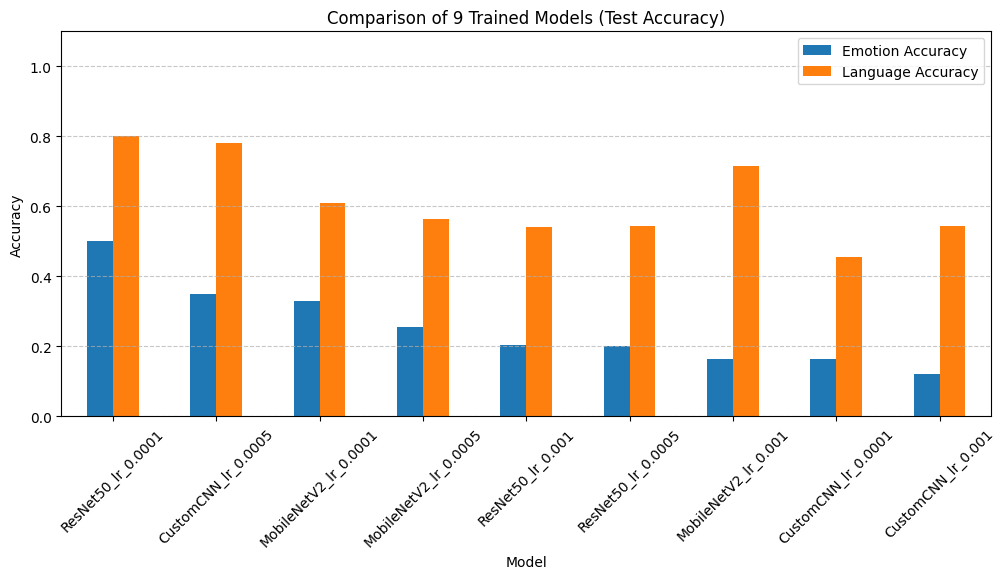


📈 TRAINING & VALIDATION LEARNING CURVES



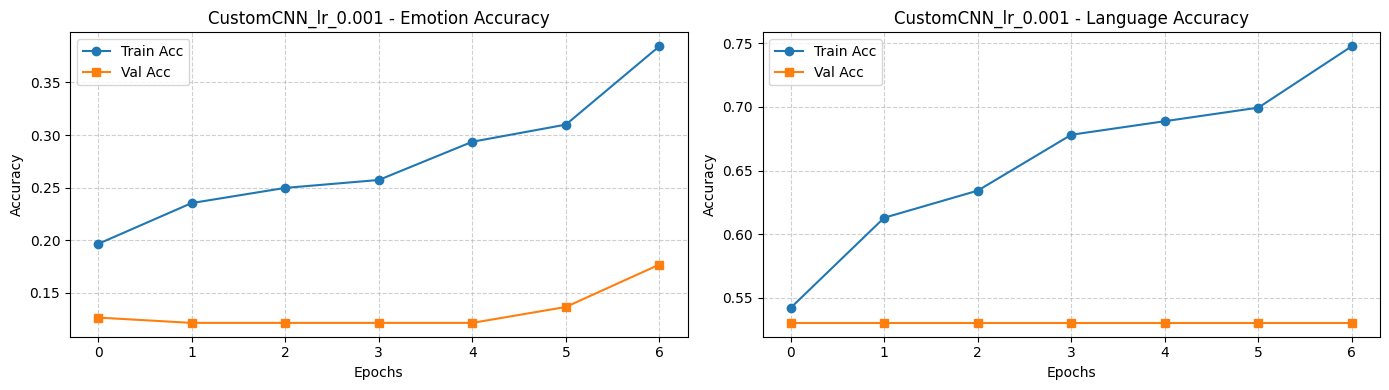

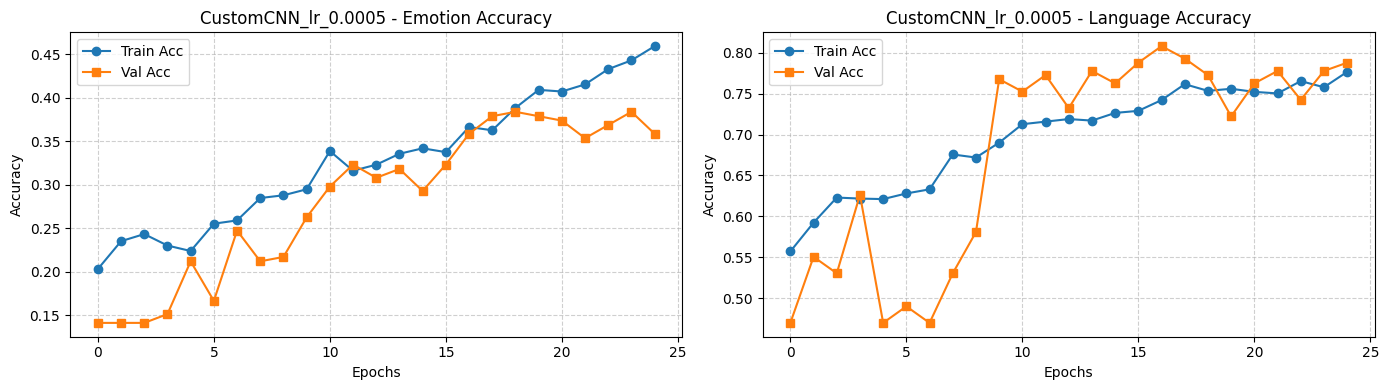

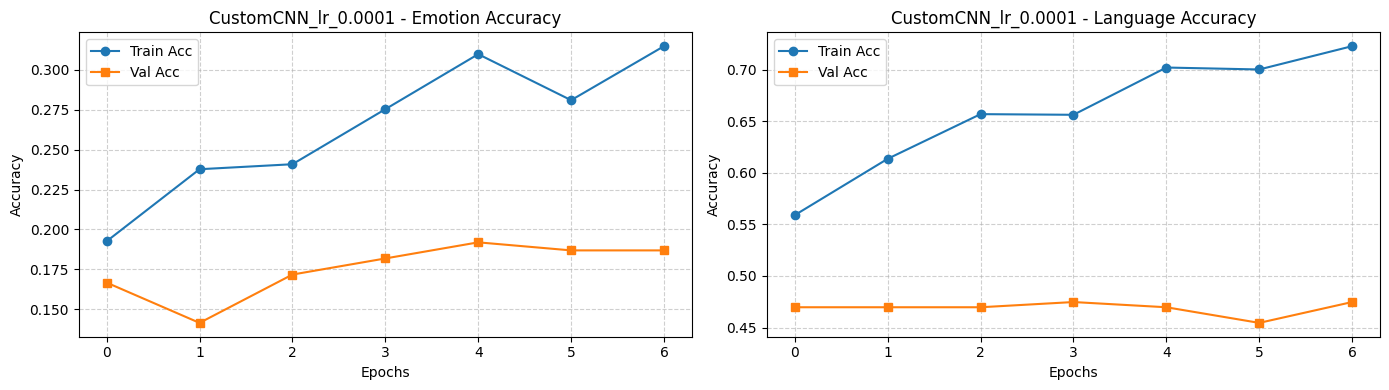

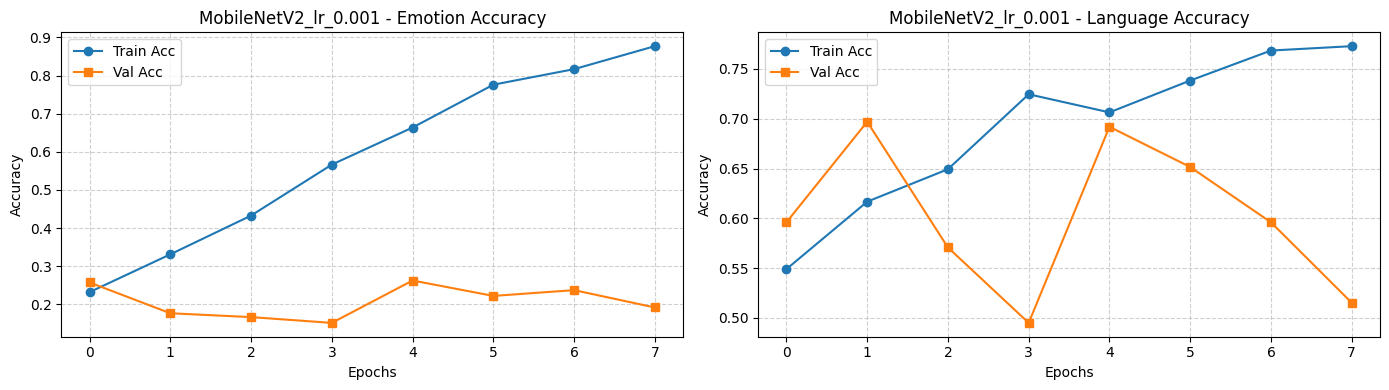

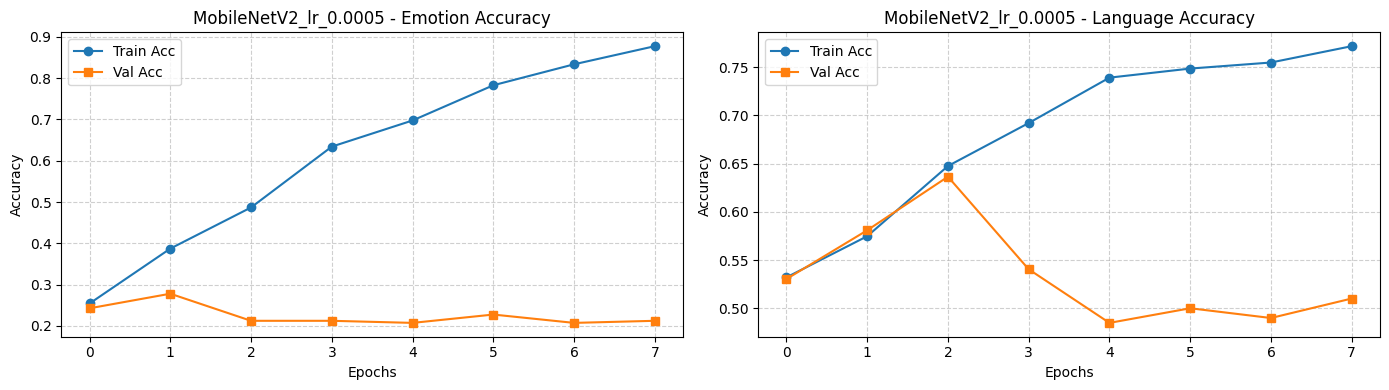

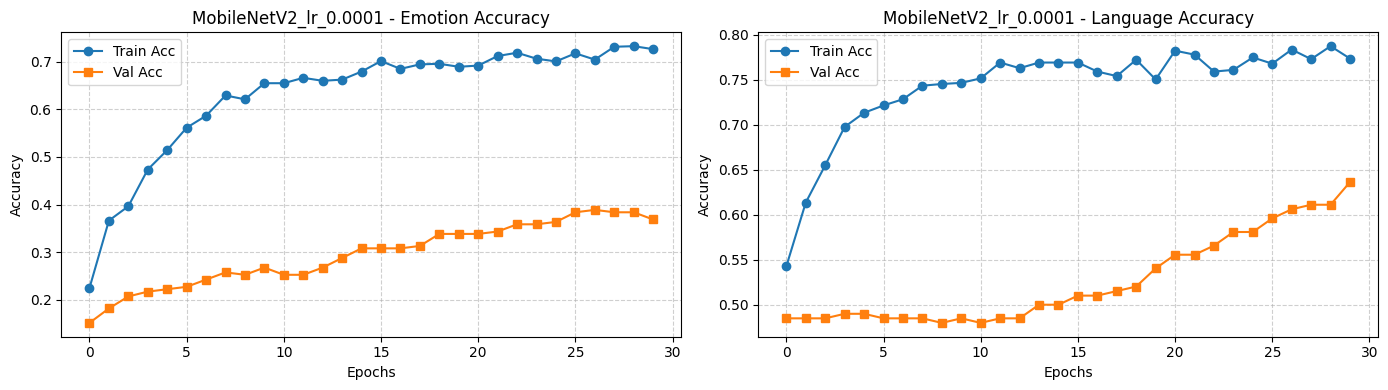

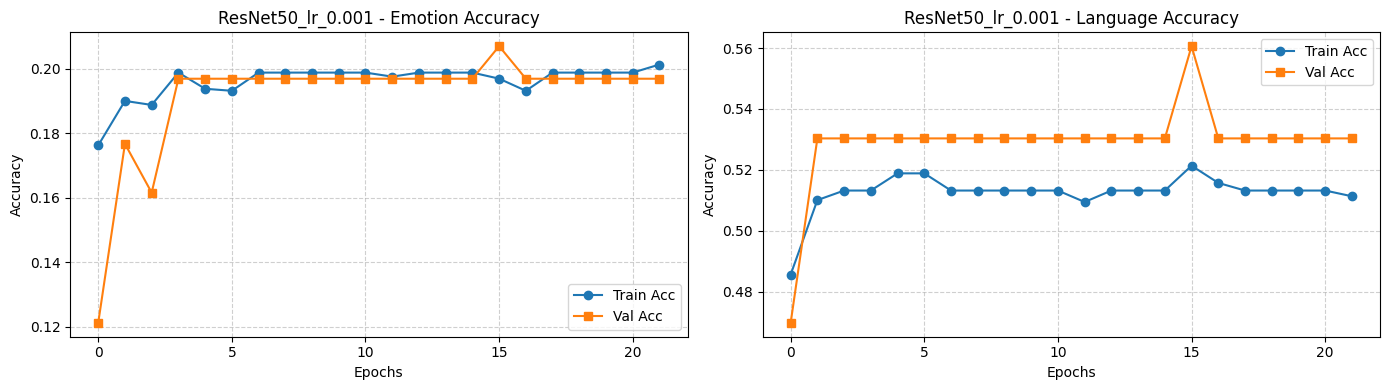

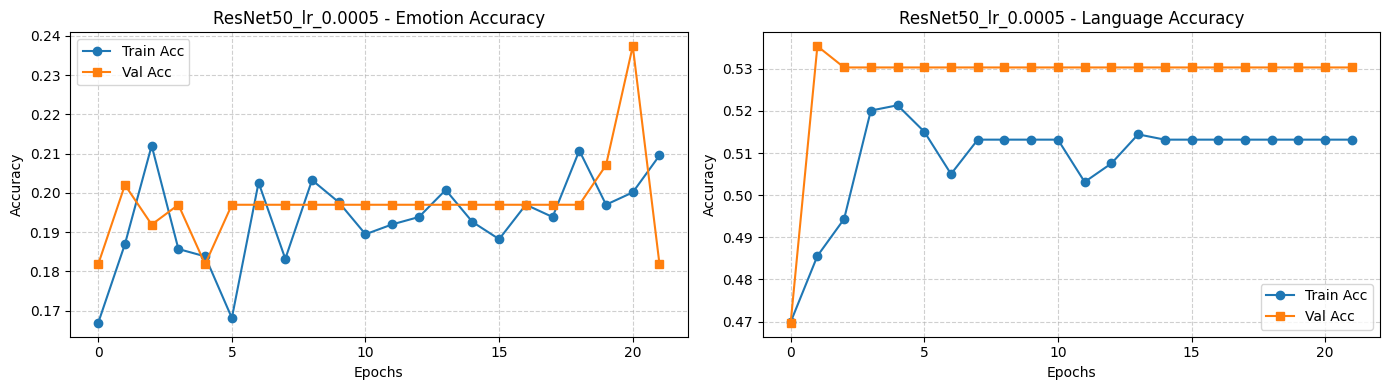

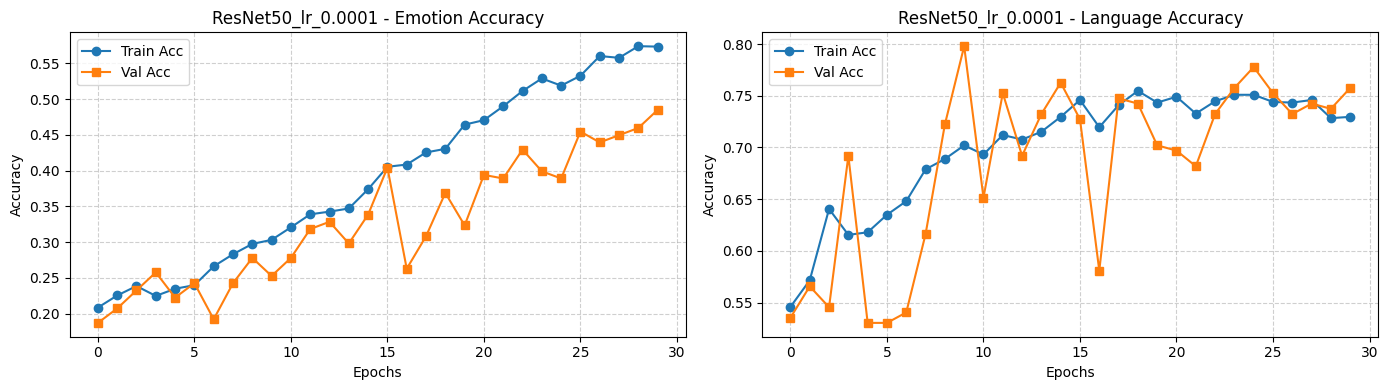

In [ ]:
df_results = pd.DataFrame(evaluation_results)
df_results.sort_values(by="Emotion Accuracy", ascending=False, inplace=True)

display(df_results)

# 1. Plotting the Bar Chart for Test Accuracies

df_results.set_index("Model")[["Emotion Accuracy", "Language Accuracy"]].plot(kind='bar', figsize=(12, 5))
plt.title("Comparison of 9 Trained Models (Test Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. NEW: Plotting Training vs Validation Accuracy over Epochs

print("\n" + "="*50)
print("📈 TRAINING & VALIDATION LEARNING CURVES")
print("="*50 + "\n")

for model_name, hist in training_histories.items():

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Keras names metrics based on the output layer names ('emotion_out', 'language_out')

    # Emotion Accuracy Plot

    if 'emotion_out_accuracy' in hist:
        axes[0].plot(hist['emotion_out_accuracy'], label='Train Acc', marker='o')
        axes[0].plot(hist['val_emotion_out_accuracy'], label='Val Acc', marker='s')
        axes[0].set_title(f'{model_name} - Emotion Accuracy')
        axes[0].set_xlabel('Epochs')
        axes[0].set_ylabel('Accuracy')
        axes[0].legend()
        axes[0].grid(True, linestyle='--', alpha=0.6)

    # Language Accuracy Plot

    if 'language_out_accuracy' in hist:
        axes[1].plot(hist['language_out_accuracy'], label='Train Acc', marker='o')
        axes[1].plot(hist['val_language_out_accuracy'], label='Val Acc', marker='s')
        axes[1].set_title(f'{model_name} - Language Accuracy')
        axes[1].set_xlabel('Epochs')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
print(f"--- Comparison for Best Model: {best_model_name} ---\n")

# Extract final metrics from history

final_train_emo = training_histories[best_model_name]['emotion_out_accuracy'][-1]
final_val_emo = training_histories[best_model_name]['val_emotion_out_accuracy'][-1]

# Get the test result for the best model

best_test_results = next(item for item in evaluation_results if item['Model'] == best_model_name)
test_acc_emo = best_test_results['Emotion Accuracy']

print("EMOTION ACCURACY COMPARISON:")
print(f"- Training Accuracy:   {final_train_emo:.4f}")
print(f"- Validation Accuracy: {final_val_emo:.4f}")
print(f"- Test Accuracy:       {test_acc_emo:.4f}")

print("\nLANGUAGE ACCURACY COMPARISON:")
final_train_lang = training_histories[best_model_name]['language_out_accuracy'][-1]
final_val_lang = training_histories[best_model_name]['val_language_out_accuracy'][-1]
test_acc_lang = best_test_results['Language Accuracy']

print(f"- Training Accuracy:   {final_train_lang:.4f}")
print(f"- Validation Accuracy: {final_val_lang:.4f}")
print(f"- Test Accuracy:       {test_acc_lang:.4f}")

--- Comparison for Best Model: ResNet50_lr_0.0001 ---

EMOTION ACCURACY COMPARISON:
- Training Accuracy:   0.5734
- Validation Accuracy: 0.4848
- Test Accuracy:       0.5000

LANGUAGE ACCURACY COMPARISON:
- Training Accuracy:   0.7296
- Validation Accuracy: 0.7576
- Test Accuracy:       0.8000


In [ ]:
EMOTION_MAP = {0: "Calm", 1: "Happy", 2: "Sad", 3: "Stressed", 4: "Excited", 5: "Angry"}
LANG_MAP = {0: "English", 1: "Urdu"}

# UI Elements

title = widgets.HTML("<h2>Audio Emotion & Language Predictor</h2>")
file_input = widgets.Text(description="Audio Path:", placeholder="Enter path to .webm or .wav file...")
predict_btn = widgets.Button(description="Predict", button_style="success")
output_area = widgets.Output()

def preprocess_live_audio(filepath):

    # Same exact logic applied in features.py

    y, sr = librosa.load(filepath, sr=16000)
    yt, _ = librosa.effects.trim(y, top_db=30) # Trim silence
    S = librosa.feature.melspectrogram(y=yt, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    S_norm = cv2.normalize(S_dB, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    img_resized = cv2.resize(S_norm, (224, 224), interpolation=cv2.INTER_CUBIC)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)

    # Expand to match model batch input shape (1, 224, 224, 3)

    return np.expand_dims(img_rgb, axis=0).astype(np.float32) / 255.0

def on_predict_click(b):

    with output_area:
        clear_output()

        if not file_input.value:
            print("❌ Please enter a valid file path.")

            return

        try:

            print(f"Processing audio: {file_input.value}...")
            X_input = preprocess_live_audio(file_input.value)

            # Predict using the best model from the loop

            preds = best_model.predict(X_input, verbose=0)
            emo_pred = np.argmax(preds[0][0])
            lang_pred = 1 if preds[1][0][0] > 0.5 else 0

            print("\n" + "="*30)
            print("🎯 PREDICTION RESULTS")
            print("="*30)
            print(f"🗣️ Language : {LANG_MAP[lang_pred]}")
            print(f"🎭 Emotion  : {EMOTION_MAP[emo_pred]}")

        except Exception as e:

            print(f"❌ Error processing file: {e}")

predict_btn.on_click(on_predict_click)

display(title, file_input, predict_btn, output_area)

HTML(value='<h2>Audio Emotion & Language Predictor</h2>')

Text(value='', description='Audio Path:', placeholder='Enter path to .webm or .wav file...')

Button(button_style='success', description='Predict', style=ButtonStyle())

Output()